# Module 1.1 — What is CFD?

**The core idea in one sentence:** CFD turns the continuous physics of fluid flow — described by partial differential equations — into a finite set of numbers that a computer can crunch.

**Why this matters before anything else:**
Every solver you write in this curriculum is doing one thing: approximating reality with numbers on a grid. If you don't understand *why* that approximation is necessary, you will misuse every result it gives you.

**What this module covers:**
1. Why analytical solutions to fluid equations are essentially impossible for real geometries
2. The mosaic idea — how discretisation makes the impossible tractable
3. The six-step CFD pipeline — the mental model for everything that follows
4. CFD vs. experiment vs. theory — what each method is actually good for
5. What the Navier-Stokes equations say in plain English
6. A first look at a real CFD solution

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Why Analytical Solutions Are Rare

### The textbook illusion

In a fluids textbook you can solve for the velocity profile in a pipe (Hagen-Poiseuille), the drag on a sphere at very low speed (Stokes drag), or the lift on an infinite flat plate (thin-airfoil theory). These are elegant closed-form results. They suggest that with enough cleverness you could always find a formula.

That impression is completely wrong.

All those textbook solutions share two features: **trivially simple geometry** (infinite plate, infinite pipe, perfect sphere) and **strong simplifying assumptions** (steady, incompressible, inviscid, laminar, 2D, ...). Remove even one of those assumptions — put a bump on the pipe wall, add a corner, let the flow become turbulent — and the analytical solution vanishes.

### Why the Navier-Stokes equations resist analysis

The momentum equation for an incompressible fluid is:

$$\frac{\partial \mathbf{u}}{\partial t} + \underbrace{(\mathbf{u} \cdot \nabla)\mathbf{u}}_{\text{this term}} = -\frac{\nabla p}{\rho} + \nu \nabla^2 \mathbf{u}$$

The highlighted term — the **nonlinear convective term** — is the problem. It means: the velocity field transports itself. The flow carries the very momentum that determines how it flows. This circularity creates a nonlinear PDE where the unknown ($\mathbf{u}$) appears multiplied by its own derivative. Nonlinear PDEs almost never have exact solutions for non-trivial domains.

This is not a gap in our mathematical knowledge — it is a structural property of the equations. The Clay Mathematics Institute has offered **$1,000,000** to anyone who can prove (or disprove) that smooth solutions to 3D N-S always exist. As of 2025, the prize is unclaimed.

### The CFD way out

Instead of solving the PDE exactly everywhere, CFD solves it **approximately at a finite number of points**. The continuous domain is replaced by a discrete grid; continuous derivatives are replaced by algebraic differences between neighbouring grid values; and the PDE becomes a large system of ordinary equations that a computer can solve.

The approximation can be made as accurate as desired by refining the grid. The cost of doing so is more computation — this is the fundamental trade-off in all of CFD.

## 2. The Mosaic Idea — Discretisation

### The analogy

A mosaic reproduces the Mona Lisa using square tiles. Each tile is completely described by one colour — a single number. The combination of thousands of trivially simple tiles captures the full complexity of the original painting.

CFD does the same thing with physics.

```
Continuous domain                 Discretised domain
────────────────────              ────────────────────
u(x,y,t) — a function that        u[i,j,n] — a 3D array of
varies continuously at            numbers, one per grid
every point in space and time     point per time step

∂u/∂x — a derivative             (u[i+1,j] - u[i-1,j])/(2Δx)
defined at every point            — a difference between
                                  neighbouring array values

∂²u/∂x² — smooth curvature       (u[i+1,j]-2u[i,j]+u[i-1,j])/Δx²
                                  — one algebraic expression
```

### What is lost — and what is gained

| Property | Continuous PDE | Discrete CFD |
|----------|---------------|--------------|
| Solution space | Infinitely many values | Finite array |
| Exactness | Exact (if solvable) | Approximate — error $\sim \Delta x^p$ |
| Geometry | Any shape, in principle | Constrained by grid |
| Solvable for real problems? | Almost never | Yes, always |
| Can be refined? | N/A | Yes — halve $\Delta x$, error decreases |

The error in CFD goes to zero as the grid is refined. A coarse grid gives a rough answer; a fine grid gives a precise one. This is called **convergence** and it is how you know your CFD result is trustworthy.

## 3. The Six-Step CFD Pipeline

Every CFD simulation — from a student exercise to a full aircraft simulation — follows this sequence. Memorise it now, because every notebook in this curriculum maps onto these six steps.

```
STEP 1 — Geometry
  Define the shape of the fluid domain.
  (Unit square for cavity, airfoil profile for aero, pipe cross-section for heat transfer)

STEP 2 — Mesh generation
  Divide the domain into cells.
  Mesh quality controls both accuracy and solver stability.
  (Module 3.3 covers this in depth)

STEP 3 — Physics setup
  Choose which equations to solve (N-S, energy, turbulence transport)
  and set fluid properties (ρ, μ, k, cp).

STEP 4 — Boundary and initial conditions
  Tell the solver what happens at every boundary (inlet velocity, wall temperature, etc.)
  and what the flow looks like at t = 0.
  WRONG BCs → WRONG PHYSICS, even if the solver is perfect.

STEP 5 — Solve
  Run the iterative solver until residuals converge.
  Residual = how much the current solution violates the governing equations.
  Converged = residuals < 10⁻⁶ (typical criterion).

STEP 6 — Post-process
  Extract numbers (drag, heat flux, pressure drop) and visualise fields
  (velocity vectors, pressure contours, temperature maps).
  ALWAYS verify against an analytical solution or experiment before trusting results.
```

Steps 1–4 are **pre-processing** (typically 60–80% of the engineer's time in industrial CFD).
Step 5 is the **solver** (automated, often runs overnight).
Step 6 is **post-processing** (interpreting what the numbers mean physically).

This curriculum covers all six steps.

## 4. The Navier-Stokes Equations in Plain English

The governing equations of incompressible flow are two statements:

### Statement 1 — Continuity (mass conservation)

$$\nabla \cdot \mathbf{u} = 0$$

**Plain English:** For every fluid parcel, what flows in must flow out. The velocity field has zero divergence — fluid is not created or destroyed anywhere.

In 2D: $\dfrac{\partial u}{\partial x} + \dfrac{\partial v}{\partial y} = 0$ — if the flow speeds up in $x$, it must slow down in $y$ to compensate.

### Statement 2 — Momentum (Newton's second law)

$$\underbrace{\frac{\partial \mathbf{u}}{\partial t}}_{\substack{\text{rate of change}\\\text{of momentum}}} + \underbrace{(\mathbf{u} \cdot \nabla) \mathbf{u}}_{\substack{\text{momentum carried}\\\text{by the flow}}} = \underbrace{-\frac{\nabla p}{\rho}}_{\substack{\text{pressure}\\\text{pushes fluid}}} + \underbrace{\nu \nabla^2 \mathbf{u}}_{\substack{\text{viscosity}\\\text{smooths velocity}}}$$

**Plain English:** The left side is $ma$ per unit volume — the rate of change of a fluid parcel's momentum as it moves. The right side is the total force per unit volume: pressure gradient (fluid pushed from high to low pressure) plus viscous friction (fast layers drag slow layers).

**Why the convective term is special:** $(\mathbf{u} \cdot \nabla)\mathbf{u}$ means "the current velocity field advects the velocity field itself." This self-referential, nonlinear term is the source of turbulence, instability, and every interesting flow phenomenon. Remove it and you get Stokes flow — trivially solvable but physically uninteresting.

### The Reynolds number tells you which term dominates

Non-dimensionalise with velocity scale $U$ and length scale $L$. The ratio of convection to viscosity is:

$$Re = \frac{UL}{\nu} = \frac{\text{inertia (convective term)}}{\text{viscous diffusion}}$$

- $Re \ll 1$: viscosity dominates, flow is smooth and creeping (swimming bacteria, MEMS devices)
- $Re \sim 1$–$10^3$: both terms matter, laminar with structure (your cavity solver)
- $Re > 10^4$: inertia dominates, flow becomes turbulent
- $Re \sim 10^7$ (aircraft): inertia crushes viscosity except in a thin layer near the wall

/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_6868/1128790559.py:19: RuntimeWarning: invalid value encountered in divide
  W   = U_inf * (Z_safe + R**2 / Z_safe)
/var/folders/j6/slfvk4c54yj6lt99pq5rjh8m0000gn/T/ipykernel_6868/1128790559.py:24: RuntimeWarning: invalid value encountered in divide
  dw_dz = U_inf * (1 - R**2 / Z_safe**2)   # complex velocity


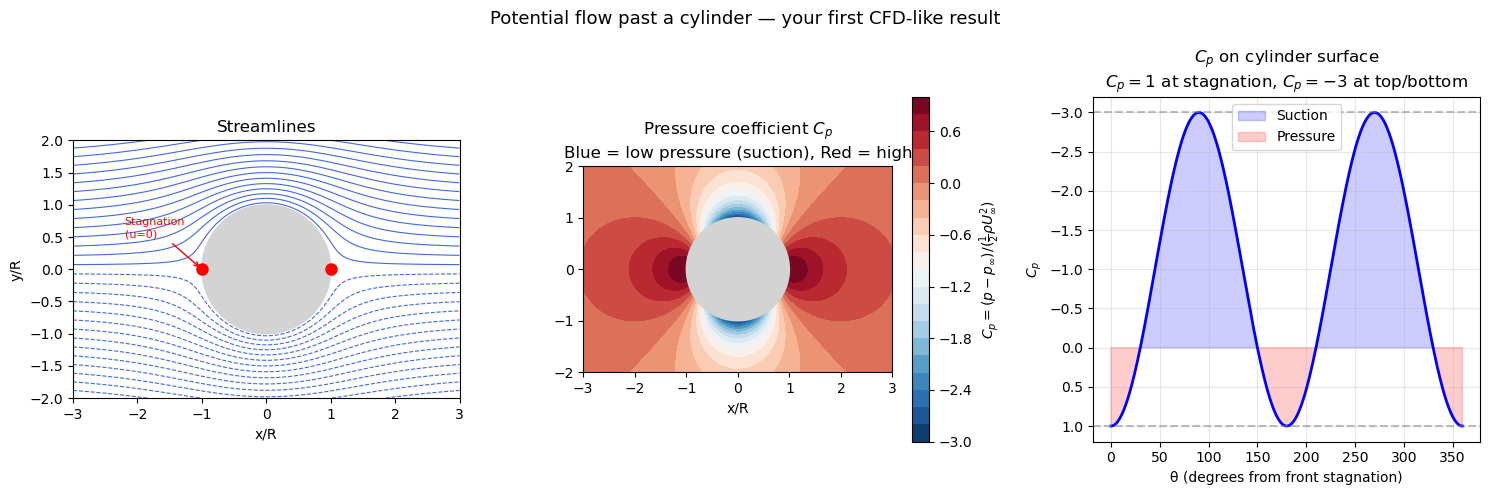

Key observations:
  1. Flow is perfectly symmetric — no wake. This is inviscid (ν=0).
     With viscosity, a wake forms (Module 2.7 shows this).
  2. Cp=1 at front stagnation — all kinetic energy converts to pressure.
     By Bernoulli: p + ½ρu² = const → u=0 gives max p.
  3. Cp=-3 at top and bottom — flow accelerates around the cylinder,
     lowering pressure. This is the mechanism of LIFT.
  4. Symmetric Cp → net force = 0 (d'Alembert paradox).
     Real viscous flow breaks the symmetry → drag exists.


In [3]:
# ── A first look at a CFD solution ──────────────────────────────────────────
# Potential flow past a cylinder: an analytical solution for inviscid flow.
# This is NOT a numerical CFD solve — it shows what CFD results look like
# and introduces the vocabulary (streamlines, stagnation, pressure coefficient).

# ── Grid ────────────────────────────────────────────────────────────────────
x = np.linspace(-3, 3, 400)
y = np.linspace(-2, 2, 300)
X, Y = np.meshgrid(x, y)

R      = 1.0   # cylinder radius
U_inf  = 1.0   # freestream speed
Z      = X + 1j * Y

# ── Potential flow complex potential: w = U∞(z + R²/z) ──────────────────────
# Inside cylinder: set to nan so it plots as a solid body
mask = (X**2 + Y**2) < R**2
Z_safe = np.where(mask, np.nan + 0j, Z)
W   = U_inf * (Z_safe + R**2 / Z_safe)
psi = W.imag     # streamfunction — contours of this are streamlines
phi = W.real     # velocity potential

# ── Velocity components: u = ∂φ/∂x, v = ∂φ/∂y ─────────────────────────────
dw_dz = U_inf * (1 - R**2 / Z_safe**2)   # complex velocity
u_field =  dw_dz.real
v_field = -dw_dz.imag
speed   = np.sqrt(u_field**2 + v_field**2)

# ── Pressure coefficient: Cp = 1 - (V/U∞)² ─────────────────────────────────
Cp = 1 - (speed / U_inf)**2
Cp[mask] = np.nan

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left — streamlines
levels = np.linspace(-2.5, 2.5, 40)
axes[0].contour(X, Y, psi, levels=levels, colors='royalblue', linewidths=0.8)
axes[0].add_patch(plt.Circle((0,0), R, color='lightgray', zorder=5))
axes[0].set_aspect('equal'); axes[0].set_xlim(-3,3); axes[0].set_ylim(-2,2)
axes[0].set_title('Streamlines')
axes[0].set_xlabel('x/R'); axes[0].set_ylabel('y/R')
# Mark stagnation points
axes[0].plot([-1,1],[0,0],'ro', markersize=8, zorder=6)
axes[0].annotate('Stagnation\n(u=0)', xy=(-1,0), xytext=(-2.2, 0.5), fontsize=8,
                 arrowprops=dict(arrowstyle='->', color='red'), color='red')

# Middle — pressure coefficient
cf = axes[1].contourf(X, Y, Cp, levels=20, cmap='RdBu_r', vmin=-3, vmax=1)
plt.colorbar(cf, ax=axes[1], label='$C_p = (p-p_\\infty)/(\\frac{1}{2}\\rho U_\\infty^2)$')
axes[1].add_patch(plt.Circle((0,0), R, color='lightgray', zorder=5))
axes[1].set_aspect('equal'); axes[1].set_xlim(-3,3); axes[1].set_ylim(-2,2)
axes[1].set_title('Pressure coefficient $C_p$\nBlue = low pressure (suction), Red = high')
axes[1].set_xlabel('x/R')

# Right — Cp on cylinder surface
theta = np.linspace(0, 2*np.pi, 360)
Cp_surface = 1 - 4*np.sin(theta)**2   # exact: Cp = 1 - 4sin²θ
axes[2].plot(np.degrees(theta), Cp_surface, 'b-', linewidth=2)
axes[2].axhline(-3, color='gray', linestyle='--', alpha=0.5)
axes[2].axhline(1,  color='gray', linestyle='--', alpha=0.5)
axes[2].fill_between(np.degrees(theta), Cp_surface, 0,
                     where=Cp_surface<0, alpha=0.2, color='blue', label='Suction')
axes[2].fill_between(np.degrees(theta), Cp_surface, 0,
                     where=Cp_surface>0, alpha=0.2, color='red',  label='Pressure')
axes[2].set_xlabel('θ (degrees from front stagnation)')
axes[2].set_ylabel('$C_p$')
axes[2].set_title('$C_p$ on cylinder surface\n$C_p=1$ at stagnation, $C_p=-3$ at top/bottom')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
axes[2].invert_yaxis()   # convention: Cp axis runs downward

plt.suptitle('Potential flow past a cylinder — your first CFD-like result', fontsize=13)
plt.tight_layout()
plt.show()

print('Key observations:')
print('  1. Flow is perfectly symmetric — no wake. This is inviscid (ν=0).')
print('     With viscosity, a wake forms (Module 2.7 shows this).')
print('  2. Cp=1 at front stagnation — all kinetic energy converts to pressure.')
print('     By Bernoulli: p + ½ρu² = const → u=0 gives max p.')
print('  3. Cp=-3 at top and bottom — flow accelerates around the cylinder,')
print('     lowering pressure. This is the mechanism of LIFT.')
print('  4. Symmetric Cp → net force = 0 (d\'Alembert paradox).')
print('     Real viscous flow breaks the symmetry → drag exists.')

## 5. CFD vs. Experiment vs. Theory

Each approach answers different questions and has different failure modes. A good engineer uses all three.

| Method | Best for | Key limitations | Typical cost |
|--------|---------|-----------------|---------------|
| **Theory** | Fundamental understanding; scaling laws; design intuition | Only works for simplified geometries | Zero (pencil + paper) |
| **Experiment** | Ground truth; complex flows; discovering unexpected physics | Expensive; hard to change parameters; limited measurement access | High (wind tunnels: €1k–€100k/day) |
| **CFD** | Complex geometries; parametric studies; flow visualisation inside solid walls | Only as good as the model; requires validation against experiment | Medium (compute: €1–€1000/simulation) |

### Where CFD fails — the most important thing to know before you trust a result

CFD gives you a result for every input you give it. Wrong BCs, wrong turbulence model, under-resolved mesh — it still converges and gives you beautiful contour plots. The answer will be wrong, but it won't look wrong.

**The only protection is validation:** always compare your CFD result against an analytical solution (when one exists) or experimental data. Until you have done this, your result is a hypothesis, not a prediction.

Every module in this curriculum includes a validation step. This is not optional.

## 6. Where Each Module Fits in the Pipeline

```
Module 1.1 (this)  — What CFD is and why it works
Module 1.2         — Python tools: NumPy arrays, vectorisation, Matplotlib
Modules 1.3–1.4    — Conservation laws: the physics behind every equation
Module 1.5         — Finite differences: converting PDEs to algebra
Modules 1.6–1.8    — 1D PDEs: advection, diffusion, Burgers (nonlinear)
Module 2.1         — 2D extension: same equations, new indexing complexity
Modules 2.2–2.6    — Incompressible N-S solver from scratch (FVM + SIMPLE)
Modules 2.7–2.8    — External flow: cylinder, boundary conditions
Modules 3.1–3.2    — Turbulence: RANS equations and models
Modules 3.3–3.8    — Advanced: meshing, higher-order schemes, compressible flow
Module 4           — Complete engineering projects
```

## Summary

| Concept | Key point |
|---------|----------|
| Why CFD | N-S equations have no general analytical solution for real geometries |
| How CFD | Discretise the domain into cells; replace derivatives with algebraic differences |
| Accuracy | Error $\sim \Delta x^p$ — halve grid spacing, error drops by $2^p$ |
| Pipeline | 6 steps: geometry → mesh → physics → BCs → solve → post-process |
| Governing eq. | Continuity ($\nabla\cdot\mathbf{u}=0$) + Momentum (Newton's 2nd law per unit volume) |
| Reynolds number | $Re = UL/\nu$ — ratio of inertia to viscosity; controls the flow regime |
| Critical rule | **Always validate** — a CFD result without validation is a hypothesis |

---
**Next:** Module 1.2 — Python for CFD: NumPy arrays, vectorised operations, and the slice patterns you will use in every solver.